In [1]:
# Imports e configuracao
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
import sys
sys.path.append('../pipeline')
from conexao import get_engine

# Configuracoes de visualizacao
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

engine = get_engine()
print("Conexao OK")

Conexao OK


In [2]:
# Carrega cotacoes completas
df = pd.read_sql("""
    SELECT 
        a.ticker,
        a.tipo,
        c.data,
        c.abertura,
        c.fechamento,
        c.maxima,
        c.minima,
        c.volume
    FROM cotacoes c
    JOIN ativos a ON a.id = c.ativo_id
    ORDER BY a.ticker, c.data
""", engine)

df['data'] = pd.to_datetime(df['data'])

print(f"Shape: {df.shape}")
print(f"Periodo: {df['data'].min().date()} ate {df['data'].max().date()}")
print(f"Ativos: {df['ticker'].nunique()}")
print(f"\nTipos:\n{df['tipo'].value_counts()}")
df.head()

Shape: (29190, 8)
Periodo: 2021-04-30 ate 2026-05-01
Ativos: 22

Tipos:
tipo
acao      23712
cripto     5478
Name: count, dtype: int64


,ticker,tipo,data,abertura,fechamento,maxima,minima,volume
0,ABEV3.SA,acao,2021-04-30,11.0091,10.8208,11.0815,10.7991,29652900
1,ABEV3.SA,acao,2021-05-03,10.8063,10.7194,10.8570,10.5818,25143600
2,ABEV3.SA,acao,2021-05-04,10.6759,10.6035,10.7194,10.5311,16889200
3,ABEV3.SA,acao,2021-05-05,10.6108,10.7629,10.8063,10.5528,18070800
4,ABEV3.SA,acao,2021-05-06,11.4727,11.7189,11.7986,11.3857,73311200


In [3]:
# Carrega retornos diarios da view SQL
df_retornos = pd.read_sql("""
    SELECT ticker, tipo, data, fechamento, retorno_pct
    FROM vw_retorno_diario
    ORDER BY ticker, data
""", engine)

df_retornos['data'] = pd.to_datetime(df_retornos['data'])

print(f"Shape: {df_retornos.shape}")
df_retornos.head()

Shape: (29168, 5)


,ticker,tipo,data,fechamento,retorno_pct
0,ABEV3.SA,acao,2021-05-03,10.7194,-0.94
1,ABEV3.SA,acao,2021-05-04,10.6035,-1.08
2,ABEV3.SA,acao,2021-05-05,10.7629,1.50
3,ABEV3.SA,acao,2021-05-06,11.7189,8.88
4,ABEV3.SA,acao,2021-05-07,11.7406,0.19


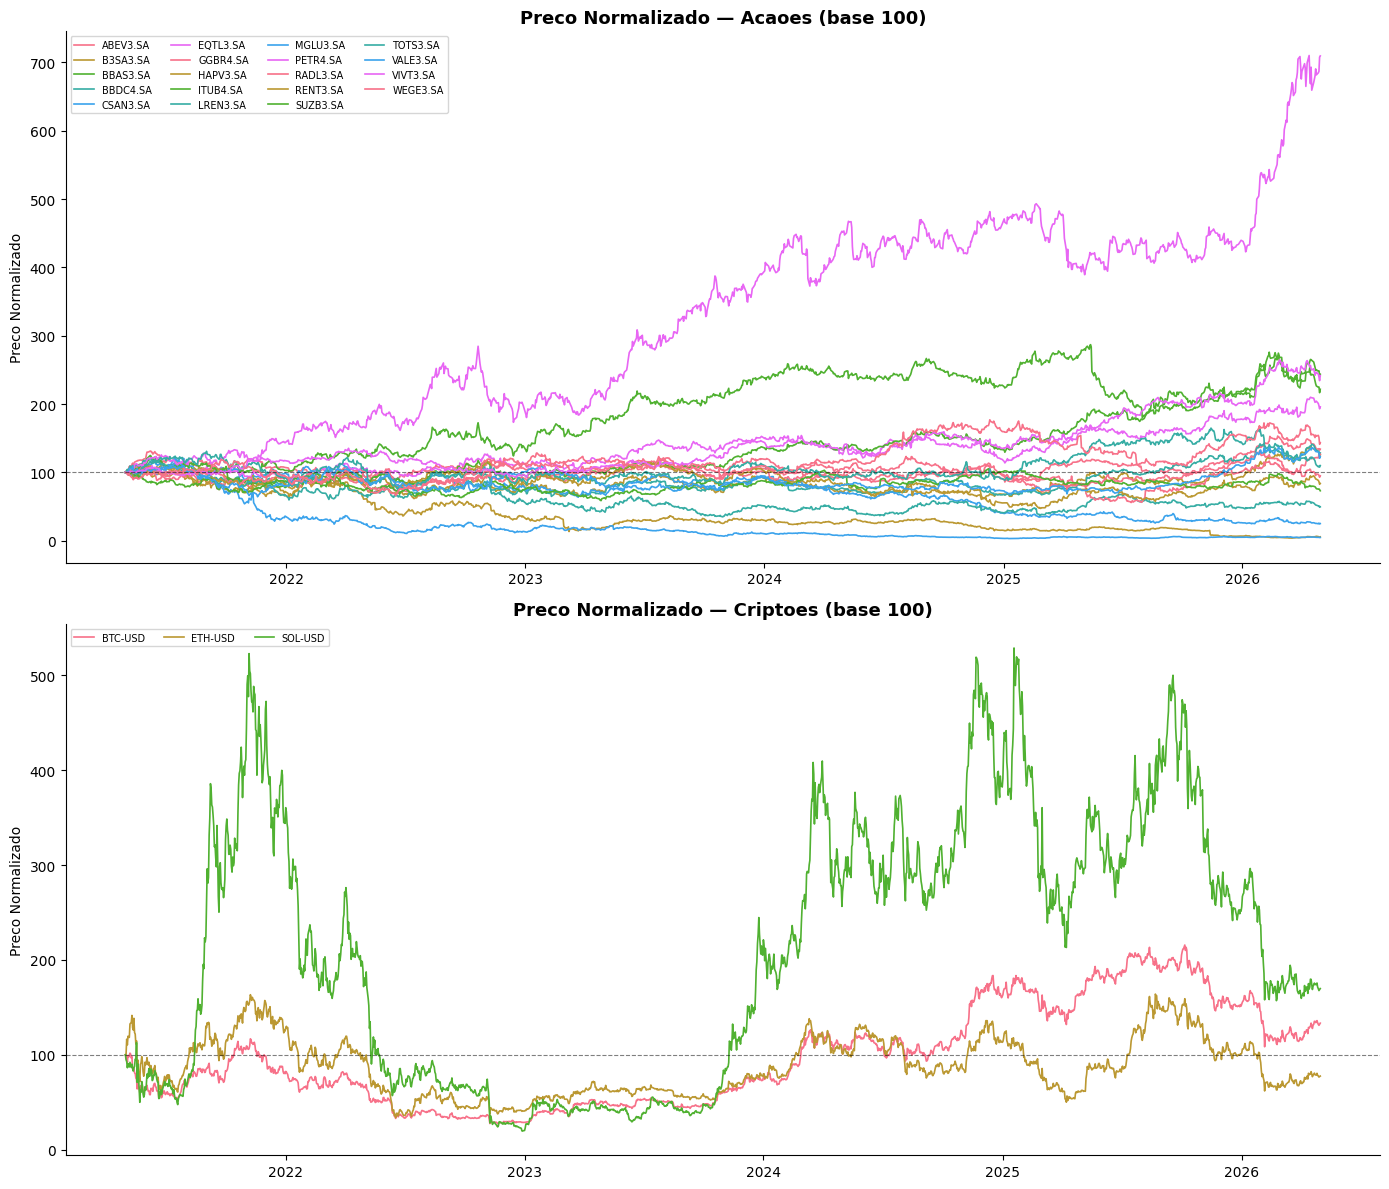

In [6]:
# Preco normalizado (base 100) para comparar todos os ativos
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for tipo, ax in zip(['acao', 'cripto'], axes):
    subset = df[df['tipo'] == tipo]
    
    for ticker in subset['ticker'].unique():
        dados = subset[subset['ticker'] == ticker].set_index('data')['fechamento']
        normalizado = (dados / dados.iloc[0]) * 100
        ax.plot(normalizado, label=ticker, linewidth=1.2)
    
    ax.set_title(f'Preco Normalizado — {tipo.capitalize()}es (base 100)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Preco Normalizado')
    ax.set_xlabel('')
    ax.legend(fontsize=7, ncol=4, loc='upper left')
    ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('../docs/preco_normalizado.png', dpi=150, bbox_inches='tight')
plt.show()

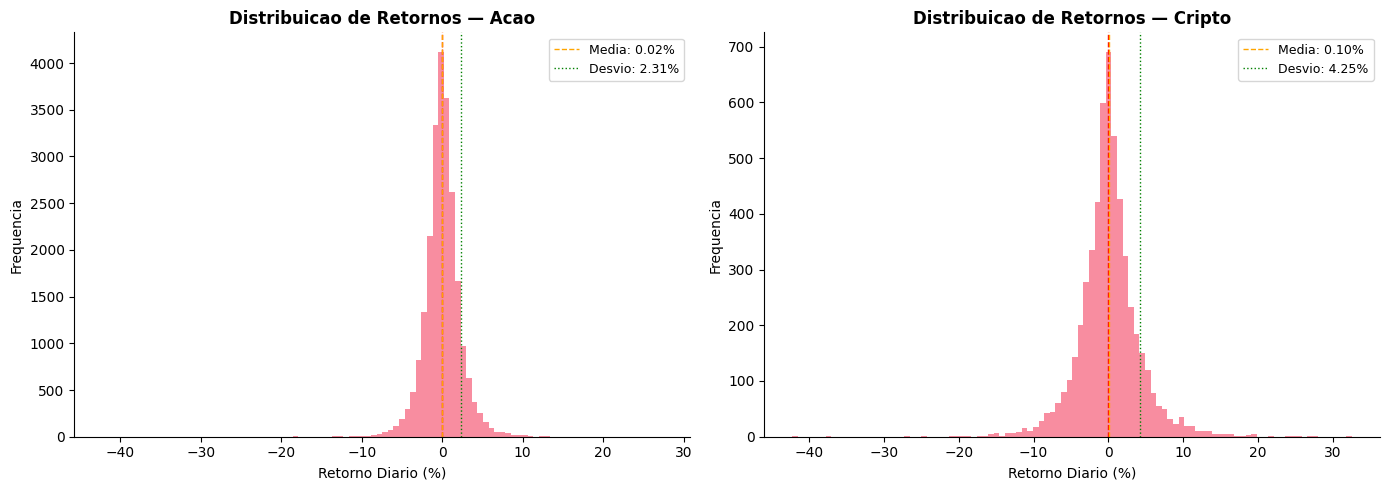

=== ACOES ===
count    23693.00
mean         0.02
std          2.31
min        -42.21
25%         -1.11
50%          0.00
75%          1.15
max         27.32
Name: retorno_pct, dtype: float64

=== CRIPTOS ===
count    5475.00
mean        0.10
std         4.25
min       -42.28
25%        -1.93
50%        -0.02
75%         1.96
max        32.59
Name: retorno_pct, dtype: float64


In [7]:
# Distribuicao dos retornos diarios por tipo de ativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tipo in zip(axes, ['acao', 'cripto']):
    dados = df_retornos[df_retornos['tipo'] == tipo]['retorno_pct'].dropna()
    
    ax.hist(dados, bins=100, edgecolor='none', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.axvline(x=dados.mean(), color='orange', linestyle='--', linewidth=1, label=f'Media: {dados.mean():.2f}%')
    ax.axvline(x=dados.std(), color='green', linestyle=':', linewidth=1, label=f'Desvio: {dados.std():.2f}%')
    
    ax.set_title(f'Distribuicao de Retornos — {tipo.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Retorno Diario (%)')
    ax.set_ylabel('Frequencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../docs/distribuicao_retornos.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatisticas descritivas
print("=== ACOES ===")
print(df_retornos[df_retornos['tipo']=='acao']['retorno_pct'].describe().round(2))
print("\n=== CRIPTOS ===")
print(df_retornos[df_retornos['tipo']=='cripto']['retorno_pct'].describe().round(2))

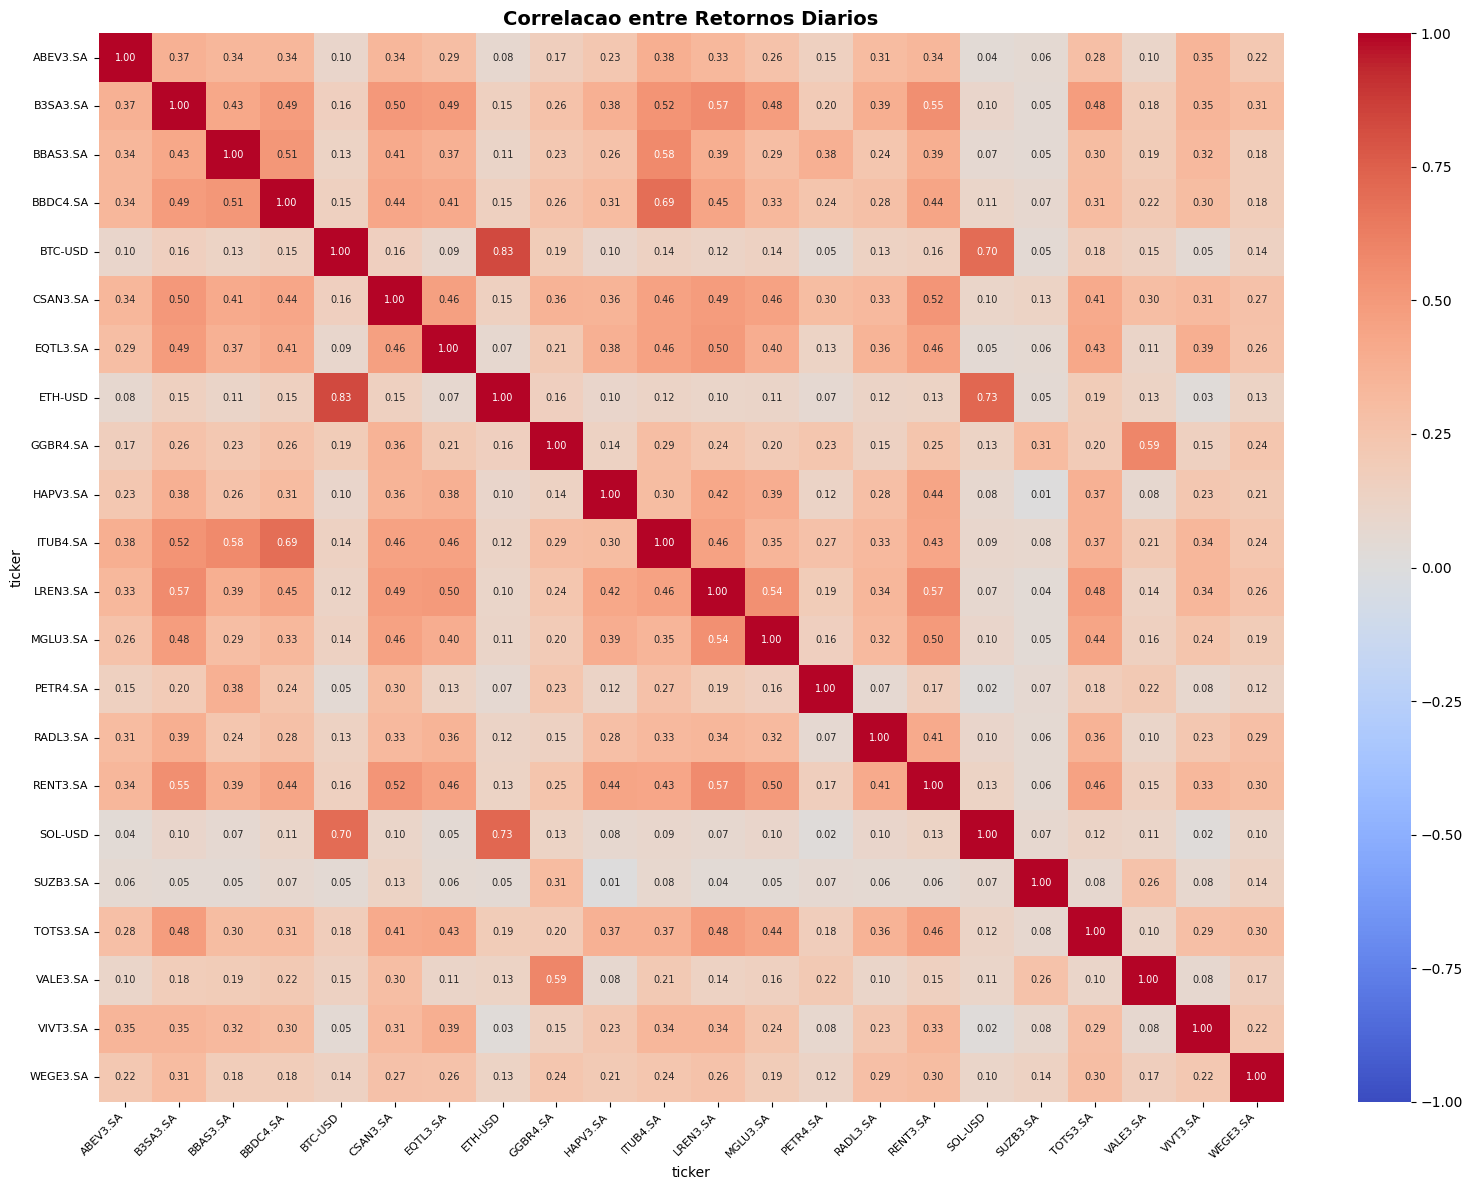

In [8]:
# Correlacao entre ativos (baseada nos retornos diarios)
retornos_pivot = df_retornos.pivot(index='data', columns='ticker', values='retorno_pct')

correlacao = retornos_pivot.corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlacao entre Retornos Diarios', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../docs/heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

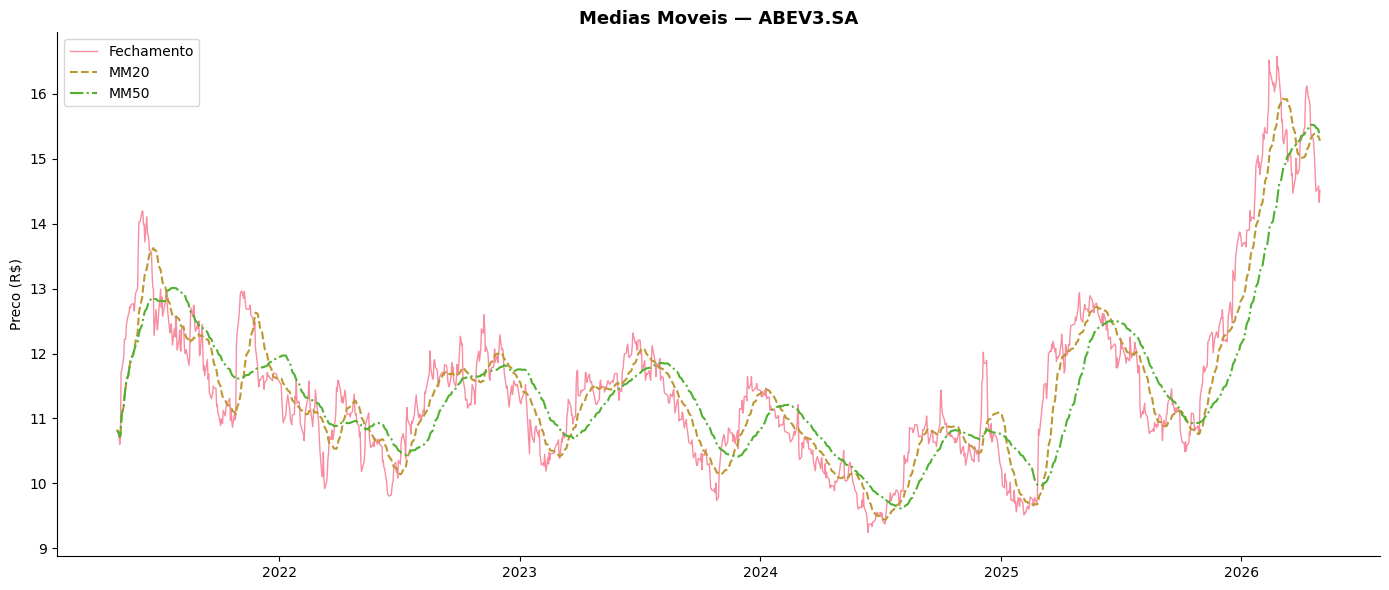

In [11]:
# Medias moveis — escolha o ticker que quiser analisar
TICKER = 'ABEV3.SA'

df_mm = pd.read_sql(f"""
    SELECT data, fechamento, mm20, mm50
    FROM vw_medias_moveis
    WHERE ticker = '{TICKER}'
    ORDER BY data
""", engine)

df_mm['data'] = pd.to_datetime(df_mm['data'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_mm['data'], df_mm['fechamento'], label='Fechamento', linewidth=1, alpha=0.8)
ax.plot(df_mm['data'], df_mm['mm20'], label='MM20', linewidth=1.5, linestyle='--')
ax.plot(df_mm['data'], df_mm['mm50'], label='MM50', linewidth=1.5, linestyle='-.')

ax.set_title(f'Medias Moveis — {TICKER}', fontsize=13, fontweight='bold')
ax.set_ylabel('Preco (R$)')
ax.legend()
plt.tight_layout()
plt.savefig(f'../docs/medias_moveis_{TICKER}.png', dpi=150, bbox_inches='tight')
plt.show()

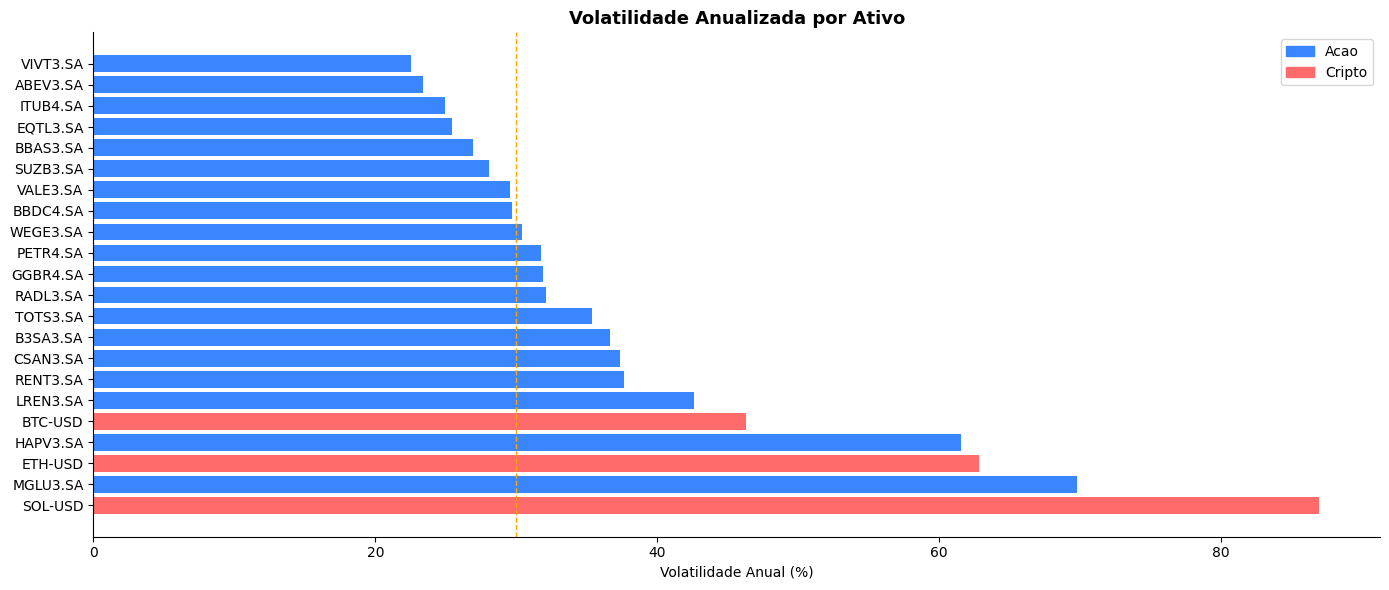

In [12]:
# Volatilidade anualizada por ativo
df_vol = pd.read_sql("""
    SELECT DISTINCT ticker, tipo, volatilidade_anual_pct
    FROM vw_volatilidade
    ORDER BY volatilidade_anual_pct DESC
""", engine)

fig, ax = plt.subplots(figsize=(14, 6))

cores = df_vol['tipo'].map({'acao': '#3A86FF', 'cripto': '#FF6B6B'})

bars = ax.barh(df_vol['ticker'], df_vol['volatilidade_anual_pct'], color=cores)
ax.axvline(x=30, color='orange', linestyle='--', linewidth=1, label='Referencia 30%')
ax.set_title('Volatilidade Anualizada por Ativo', fontsize=13, fontweight='bold')
ax.set_xlabel('Volatilidade Anual (%)')

# Legenda manual
from matplotlib.patches import Patch
legenda = [Patch(color='#3A86FF', label='Acao'), Patch(color='#FF6B6B', label='Cripto')]
ax.legend(handles=legenda)

plt.tight_layout()
plt.savefig('../docs/volatilidade.png', dpi=150, bbox_inches='tight')
plt.show()

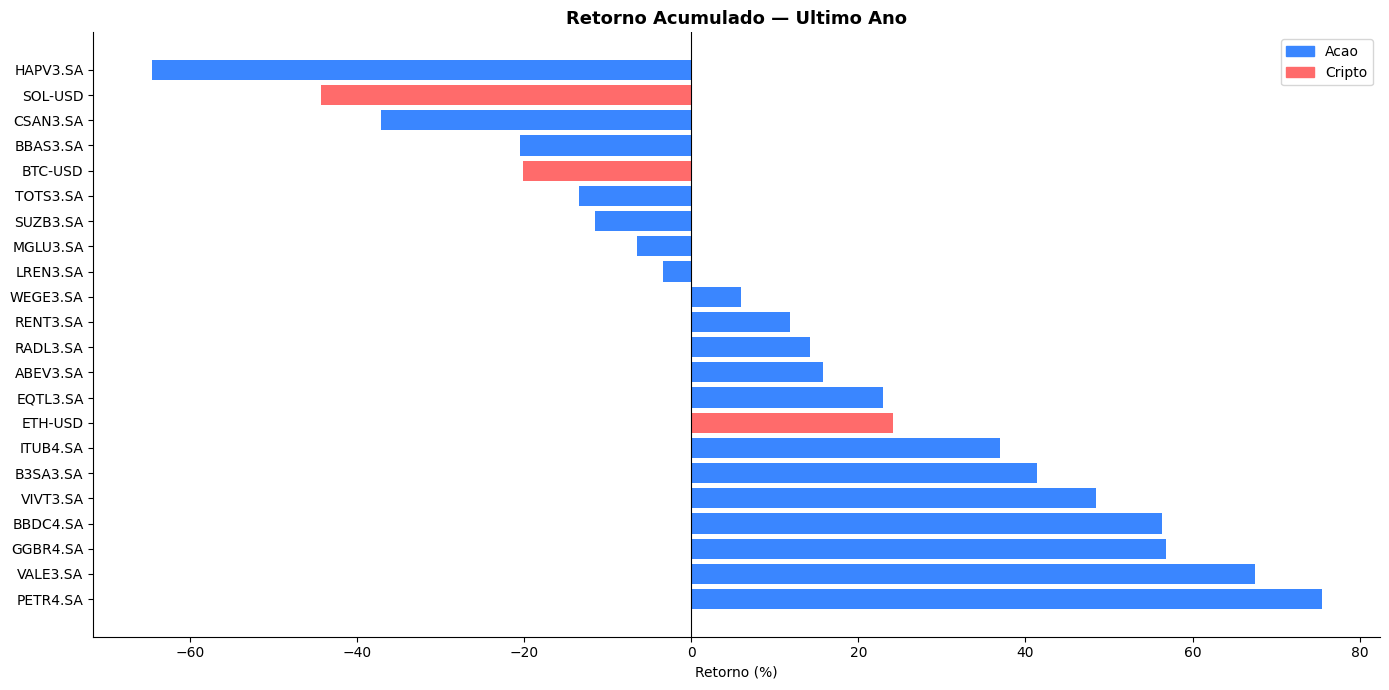

In [13]:
# Ranking de retorno acumulado no ultimo ano
df_rank = pd.read_sql("""
    SELECT ticker, tipo, retorno_1ano_pct, ranking
    FROM vw_ranking_retorno
    ORDER BY ranking
""", engine)

fig, ax = plt.subplots(figsize=(14, 7))

cores = df_rank['tipo'].map({'acao': '#3A86FF', 'cripto': '#FF6B6B'})

ax.barh(df_rank['ticker'], df_rank['retorno_1ano_pct'], color=cores)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Retorno Acumulado — Ultimo Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno (%)')

from matplotlib.patches import Patch
legenda = [Patch(color='#3A86FF', label='Acao'), Patch(color='#FF6B6B', label='Cripto')]
ax.legend(handles=legenda)

plt.tight_layout()
plt.savefig('../docs/ranking_retorno.png', dpi=150, bbox_inches='tight')
plt.show()

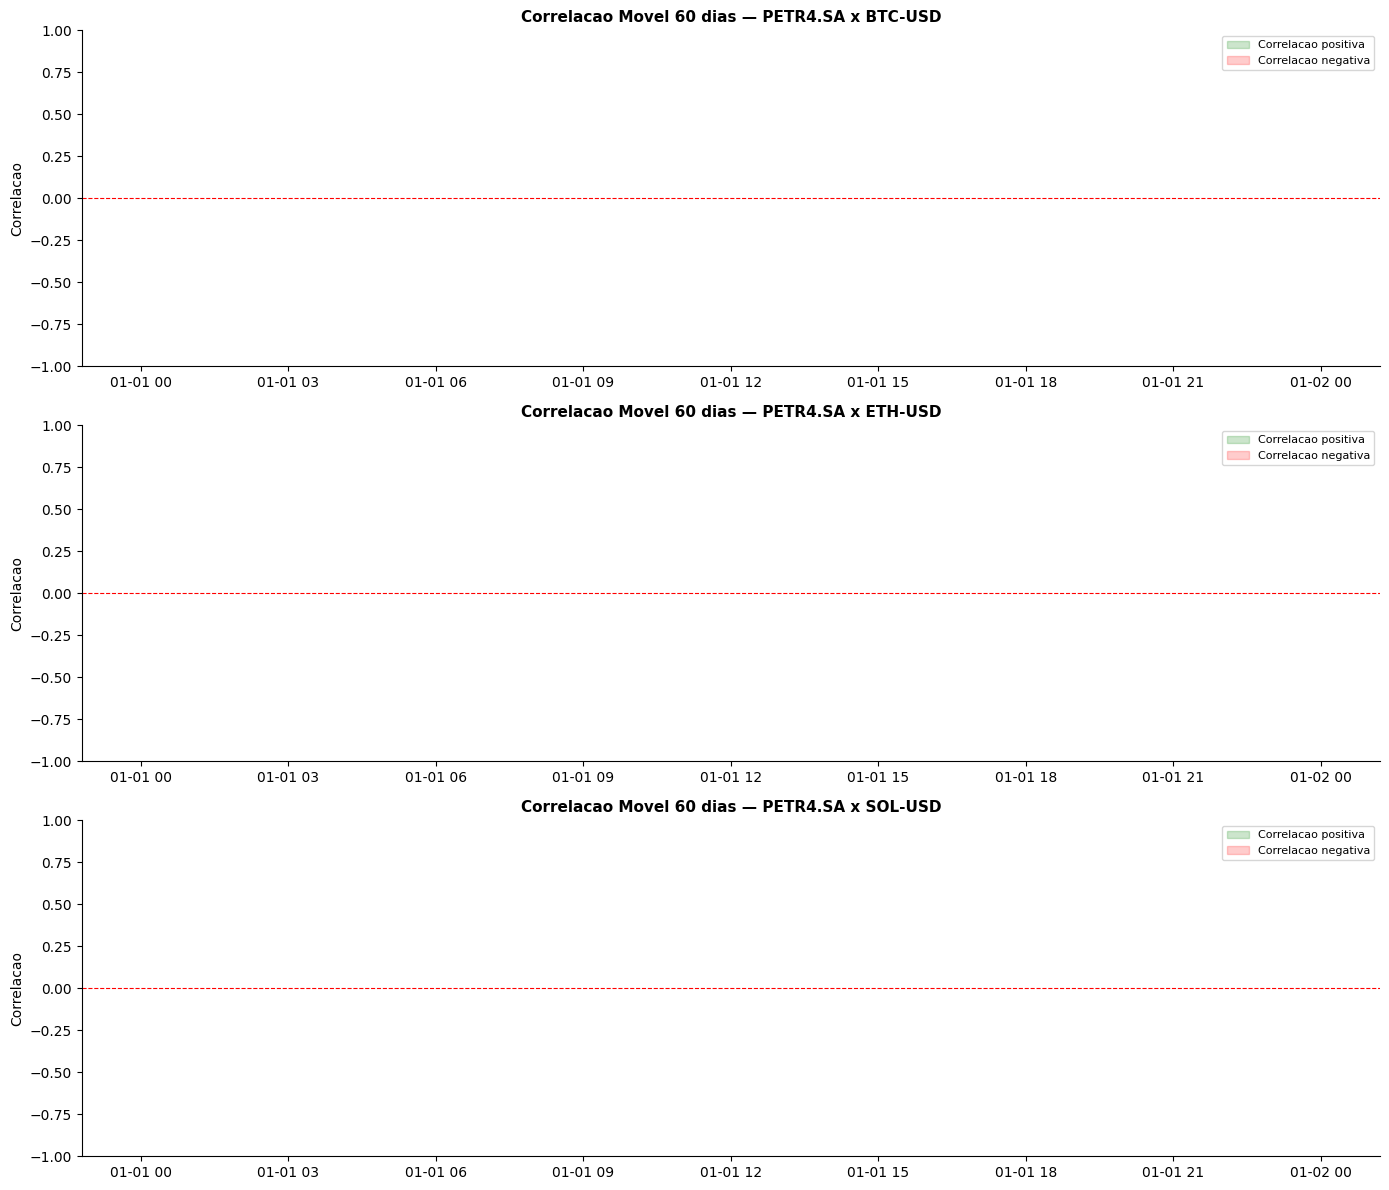

In [14]:
# Correlacao cripto x acoes ao longo do tempo (janela movel de 60 dias)
retornos_pivot = df_retornos.pivot(index='data', columns='ticker', values='retorno_pct')

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

acoes_ref = 'PETR4.SA'
criptos = ['BTC-USD', 'ETH-USD', 'SOL-USD']

for ax, cripto in zip(axes, criptos):
    corr_movel = retornos_pivot[acoes_ref].rolling(60).corr(retornos_pivot[cripto])
    
    ax.plot(corr_movel.index, corr_movel, linewidth=1.2)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
    ax.fill_between(corr_movel.index, corr_movel, 0,
                    where=(corr_movel > 0), alpha=0.2, color='green', label='Correlacao positiva')
    ax.fill_between(corr_movel.index, corr_movel, 0,
                    where=(corr_movel < 0), alpha=0.2, color='red', label='Correlacao negativa')
    
    ax.set_title(f'Correlacao Movel 60 dias — {acoes_ref} x {cripto}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Correlacao')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../docs/correlacao_movel_cripto.png', dpi=150, bbox_inches='tight')
plt.show()